## Libraries

In [ ]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Exploratory Data Analaysis (EDA)

Inital profiling

In [2]:
df = pd.read_csv('D:\\IBM Data Analyst\\Portfolio\\Telecom Customer Analytics v2\\telecom_dataset.csv')

def initialize(df):
    print("--- Dataset Shape ---")
    print(df.shape)
    print("\n--- Missing Values ---")
    print(df.isnull().sum())
    print("\n--- Summary Statistics ---")
    display(df.describe())

initialize(df)

--- Dataset Shape ---
(1000, 15)

--- Missing Values ---
user_id                   0
age                       0
gender                    0
location                  0
plan_type                 0
monthly_fee_usd           0
data_usage_gb             0
call_minutes              0
sms_count                 0
tenure_months             0
customer_support_calls    0
network_quality_score     0
payment_method            0
monthly_revenue           0
churned                   0
dtype: int64

--- Summary Statistics ---


,user_id,age,monthly_fee_usd,data_usage_gb,call_minutes,sms_count,tenure_months,customer_support_calls,network_quality_score,monthly_revenue
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,2.000050e+07,34.736000,19.636000,9.781587,298.540779,51.276281,59.548000,1.508000,3.466600,24.55593
std,2.888194e+02,9.651085,21.545294,4.818195,189.347122,37.316302,34.545087,1.217135,0.912325,21.62285
min,2.000000e+07,15.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.00000
25%,2.000025e+07,28.000000,6.000000,6.562590,166.202932,19.467009,28.000000,1.000000,2.800000,10.82500
50%,2.000050e+07,35.000000,9.000000,9.923227,289.271657,49.051018,59.500000,1.000000,3.500000,15.38000
75%,2.000075e+07,41.000000,23.000000,13.134309,422.489369,77.991070,90.000000,2.000000,4.100000,28.75500
max,2.000100e+07,73.000000,98.000000,25.760284,922.582040,167.416248,119.000000,7.000000,5.000000,105.20000


## Univariate Analysis

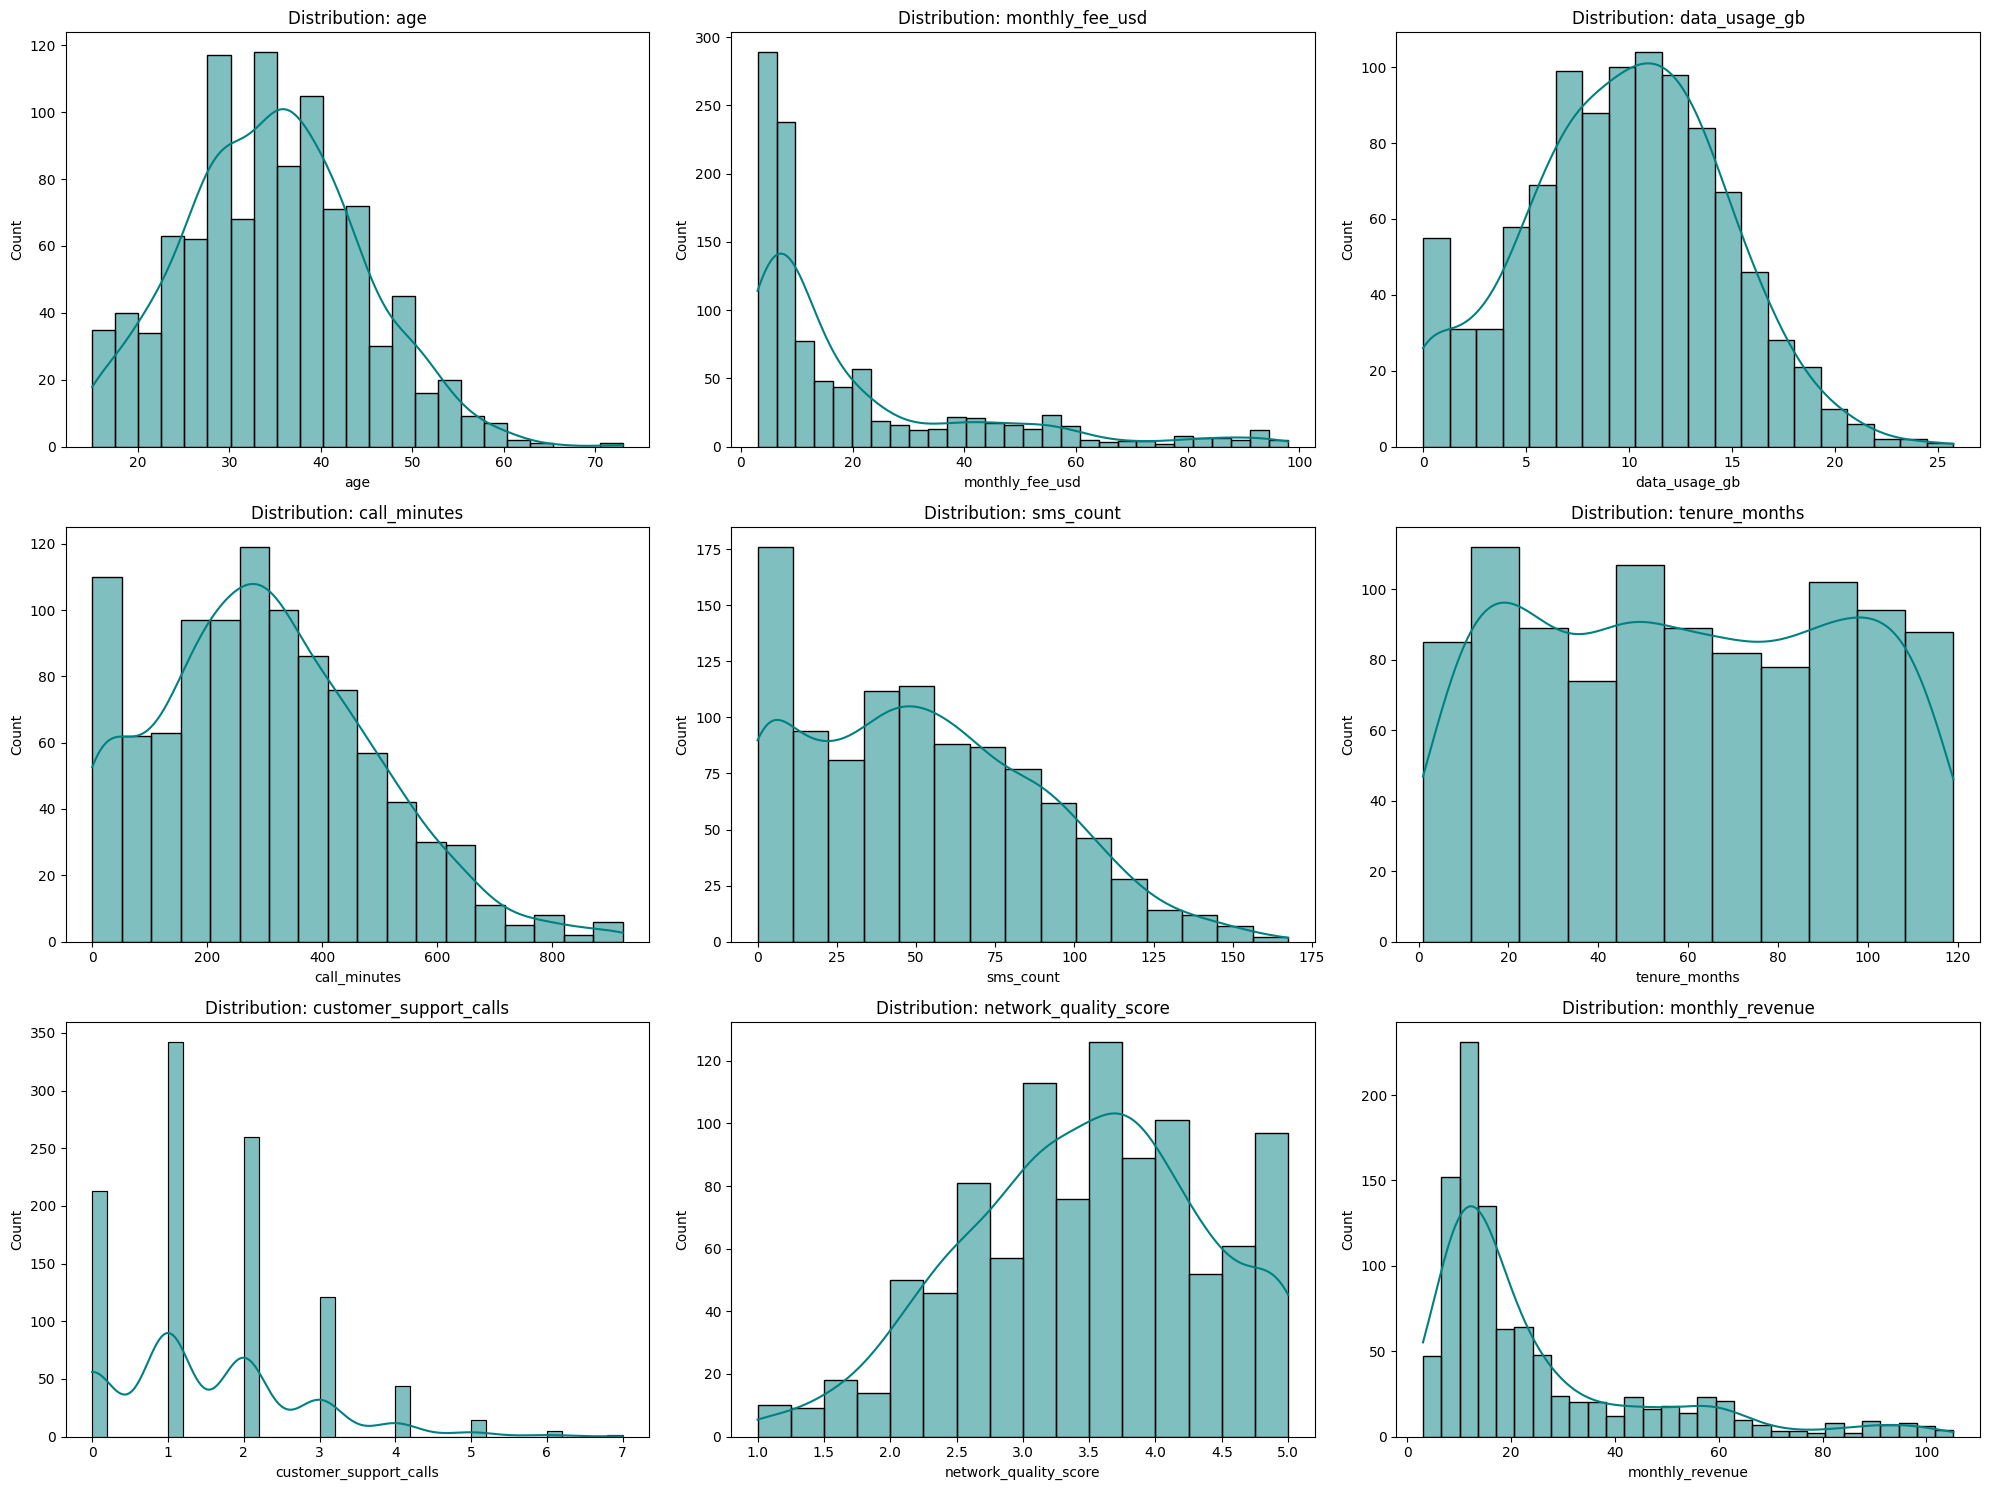

In [3]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('user_id')
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

The univariate analysis reveals a customer base centered around a **median age of 35**, with most users falling between 25 and 45 years old. Financial metrics like `monthly_fee_usd` and `monthly_revenue` show a **right-skewed distribution**, indicating that while most customers opt for low-cost plans, a significant high-value segment contributes disproportionately to revenue. Usage patterns for data, calls, and SMS appear relatively **normally distributed**, suggesting consistent consumption habits across the board. Notably, the **tenure_months** is uniform, implying a healthy mix of both new and long-term customers. Finally, the **network_quality_score** peaks between 3 and 4, showing generally positive sentiment, though the high volume of low **customer_support_calls** confirms that most users rarely need to reach out for assistance.

## Bivariate Analysis

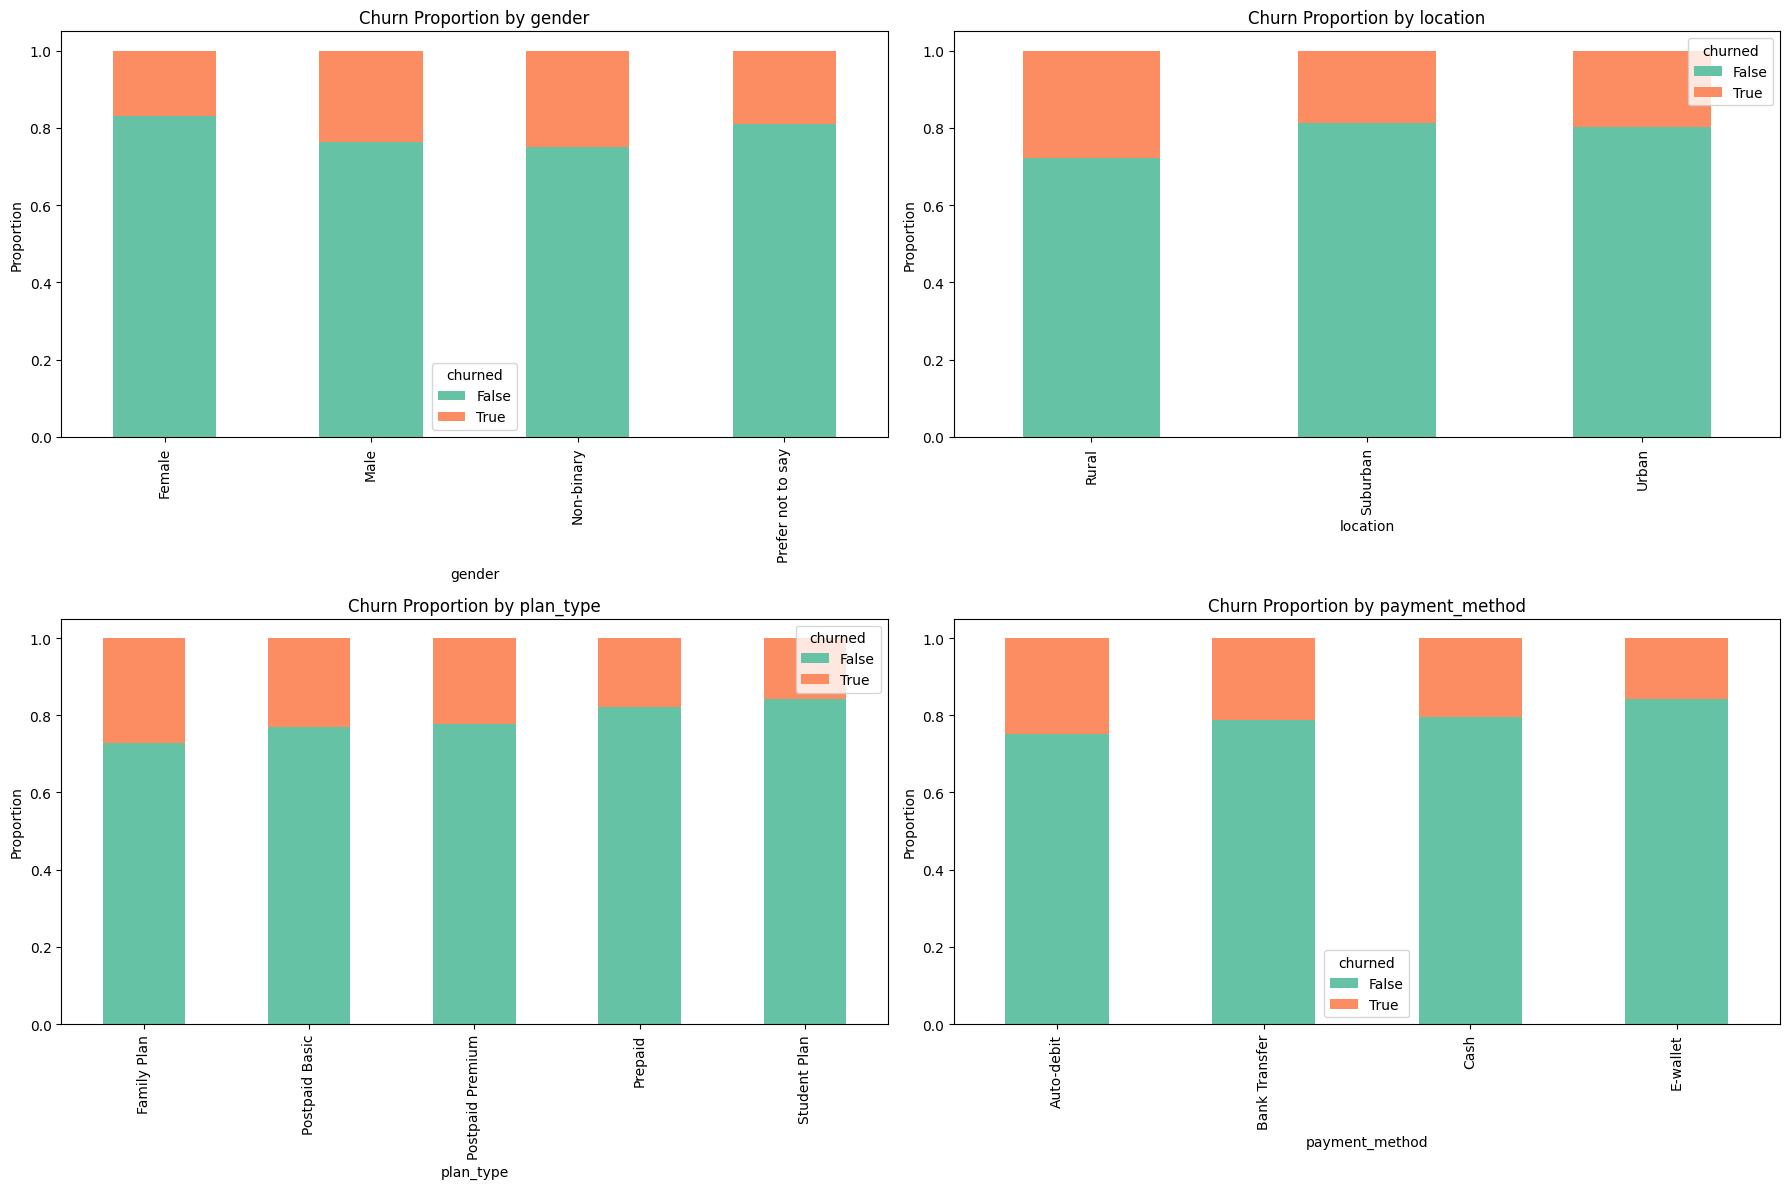

In [4]:
cat_cols = ['gender', 'location', 'plan_type', 'payment_method']
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for i, col in enumerate(cat_cols):
    row, col_idx = divmod(i, 2)
    # Calculate churn percentages for labels
    prop_df = df.groupby(col)['churned'].value_counts(normalize=True).unstack()
    prop_df.plot(kind='bar', stacked=True, ax=axes[row, col_idx], color=['#66c2a5', '#fc8d62'])
    axes[row, col_idx].set_title(f'Churn Proportion by {col}')
    axes[row, col_idx].set_ylabel('Proportion')
plt.tight_layout()
plt.show()

**By Plan Type**  
Customers on the *Family Plan* and *Postpaid Basic* segments exhibit higher churn rates relative to other plans.  
- **Family Plan**: The churn pattern may indicate dissatisfaction with how shared benefits are allocated across members, potentially reflecting a mismatch between perceived and actual value distribution.  
- **Postpaid Basic**: As an entry-level offering, this plan may not meet customer expectations in terms of features or service quality, contributing to elevated attrition.

**By Payment Method**  
Higher churn is observed among customers using *cash* and *e-wallet* payment methods. This could suggest the presence of transactional friction (e.g., inconvenience, lack of automation, or reliability concerns) that negatively impacts retention.

**By Location**  
Churn is disproportionately higher in *urban* areas. A likely driver is increased market competition, where customers have greater access to alternative providers and may switch in response to more attractive pricing, service quality, or customer experience.

**Implication**  
These patterns point to potential improvement areas in plan design, payment experience optimization, and competitive positioning in urban markets.

# Business Questions Analysis

## 1. What is the overall churn rate and how much revenue is at risk? 

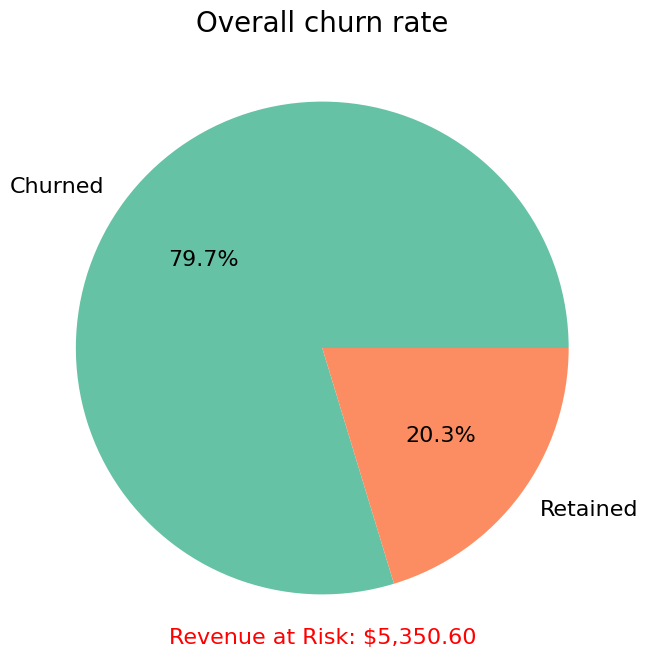

In [5]:
# Pie chart for overall churn rate
# Data
labels = ['Churned', 'Retained']
sizes = df['churned'].value_counts()

# Plot
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], textprops={'fontsize': 16})

# Number of revenue at risk
revenue_at_risk = df[df['churned'] == 1]['monthly_revenue'].sum()

plt.title("Overall churn rate", fontsize=20)
plt.text(0, -1.2, f"Revenue at Risk: ${revenue_at_risk:,.2f}", ha='center', fontsize=16, color='red')
plt.show()



## 2.	Which plan type has the highest churn rate? 

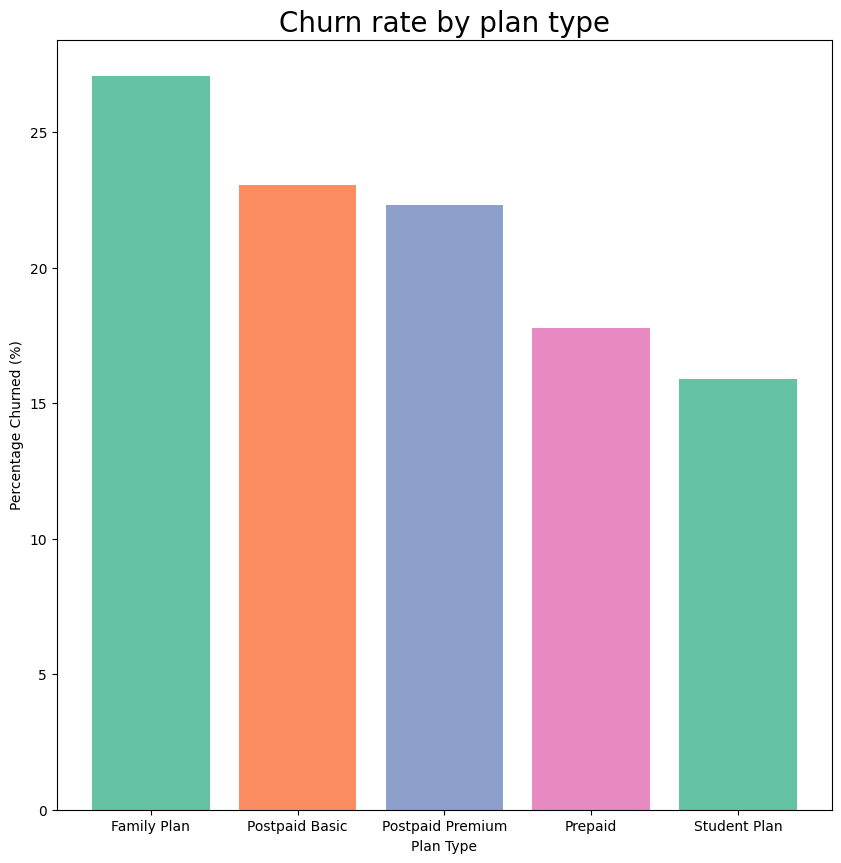

In [6]:
import matplotlib.pyplot as plt

# Data
plan_types= df.groupby('plan_type').size().index.tolist()
churn_rates = df.groupby('plan_type')['churned'].mean() * 100

# Plot
plt.figure(figsize=(10, 10))
plt.bar(plan_types, churn_rates, color=['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'])

plt.title("Churn rate by plan type", fontsize=20)
plt.xlabel("Plan Type")
plt.ylabel("Percentage Churned (%)")

plt.show()

## 3.	At what number of support calls does churn become near-certain? 

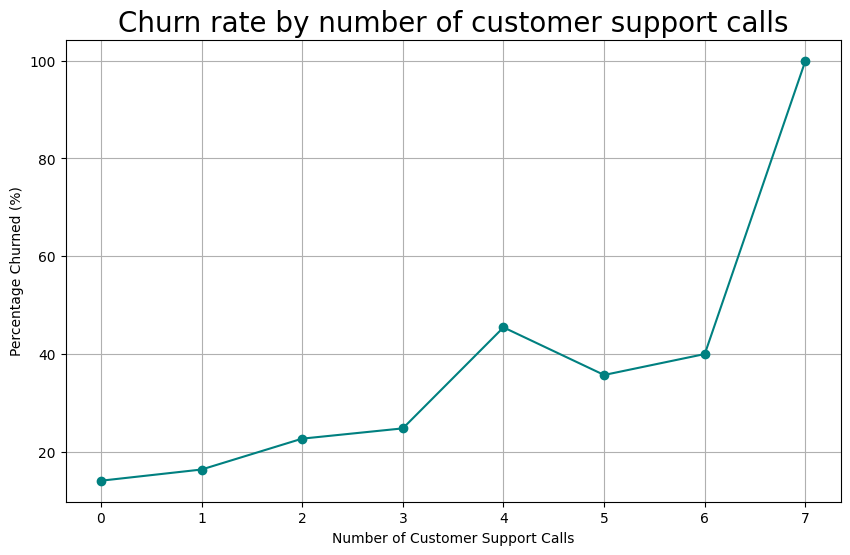

In [7]:
# Data
customer_support_calls = df.groupby('customer_support_calls')['churned'].mean() * 100
# Plot
plt.figure(figsize=(10, 6))
plt.plot(customer_support_calls.index, customer_support_calls.values, marker='o', color='teal')
plt.title("Churn rate by number of customer support calls", fontsize=20)
plt.xlabel("Number of Customer Support Calls")      
plt.ylabel("Percentage Churned (%)")
plt.xticks(customer_support_calls.index)
plt.grid()
plt.show()

## 4.	How does network quality affect churn across different locations? 

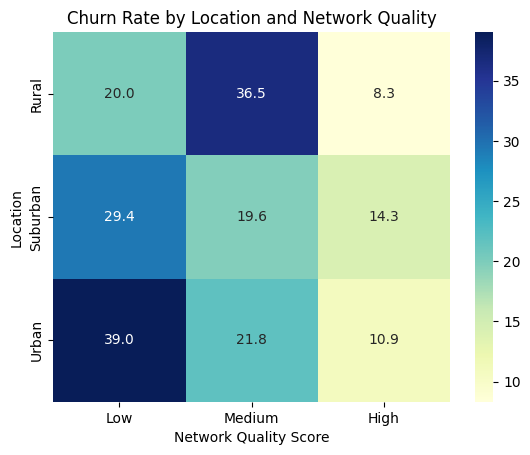

In [13]:
df['net_quality_cat'] = pd.cut(
    df['network_quality_score'], 
    bins=[0, 2, 4, 5], 
    labels=['Low', 'Medium', 'High']
)
heatmap_data = df.groupby(['location', 'net_quality_cat'])['churned'].mean() * 100
sns.heatmap(heatmap_data.unstack(), annot=True, fmt=".1f", cmap="YlGnBu")

plt.title("Churn Rate by Location and Network Quality")
plt.xlabel("Network Quality Score")
plt.ylabel("Location")
plt.show()